# SCRAMBLED: measuring quantum information scrambling on Moth Atlas and turning it into media

This notebook is the complete SCRAMBLED workflow, end to end, on [Moth Quantum's Atlas](https://docs.mothquantum.com) API:

1. **What we measure**: the out-of-time-order correlator (OTOC) $F(i,t)$ of a kicked Floquet qubit chain.
2. **Atlas API anatomy**: engine schemas, the upload, process, poll and result job lifecycle, caching and cost. The raw HTTP calls are shown once.
3. **Measure**: `otoc-echo-v1` on a scrambling circuit and on a non-scrambling control.
4. **Verify**: an independent classical statevector simulation reproduces the Atlas data to rounding error (about $10^{-13}$).
5. **New physics**: a $\theta_{zz}$ sweep (10 Atlas runs) showing scrambling switch on and off, plotted as a scrambling phase diagram.
6. **F to image**: quantum image ladders (`blur-v1`, `telablur-v1`) composed strip by strip from the measured map.
7. **F to audio**: the measured taps as a multi-tap echo, plus an attempt at `retrocausal-echo-v1`.
8. **F to video**: the `scrambled` package on an excerpt of a cooking clip.
9. **Another view of scrambling**: tomography of the same echo circuit (`tomography-api-v2`).
10. **Reproducibility and honesty**: which steps are quantum and which are classical, credits used, and a table of every job id.

**Running it.** The first code cell has a `MODE` switch. The default is `replay`: every Atlas result is read from the committed `cache/` directory, so the notebook runs with **no API key, no network and no credits**. Set `SCRAMBLED_MODE=atlas` (or edit the cell) and put `MOTH_API_KEY=...` in `.env` to run against the live API. Jobs that are already cached are not paid for again. The key is read from the environment or `.env`. It is sent only as a Bearer header and is never displayed.

Everything heavy lives in the `scrambled` package (`pip install -e .` at the repo root). The notebook calls it like a library and shows the intermediate data.

In [1]:
import os, sys, json, math, time, re, shutil, dataclasses, subprocess, hashlib
from pathlib import Path

MODE = os.environ.get("SCRAMBLED_MODE", "replay")   # "replay" (default: cache only, no key) | "atlas" (live API)
assert MODE in ("replay", "atlas"), MODE

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scrambled" / "__init__.py").exists())
os.chdir(ROOT)
NB, OUT, DATA = ROOT / "notebook", ROOT / "notebook" / "out", ROOT / "notebook" / "data"
OUT.mkdir(parents=True, exist_ok=True); DATA.mkdir(parents=True, exist_ok=True)

if os.name == "nt" and not shutil.which("ffmpeg"):   # pick up a freshly installed ffmpeg without restarting Jupyter
    import winreg
    def _reg_path(root, sub):
        try:
            with winreg.OpenKey(root, sub) as k:
                return winreg.QueryValueEx(k, "Path")[0]
        except OSError:
            return ""
    os.environ["PATH"] += os.pathsep + _reg_path(winreg.HKEY_LOCAL_MACHINE,
        r"SYSTEM\CurrentControlSet\Control\Session Manager\Environment") + os.pathsep + _reg_path(winreg.HKEY_CURRENT_USER, "Environment")

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown, Audio, Image as IPImage

import scrambled
from scrambled import otoc, mapping, image, audio, video, ffmpeg
from scrambled.client import AtlasClient, AtlasError, ReplayMiss, JobTimeout, cache_key, _load_key

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 100, "axes.titlesize": 11, "axes.labelsize": 10,
                     "font.size": 9, "figure.facecolor": "white"})
CMAP = "RdBu"   # every F plot: red = -1, white = 0, blue = +1

client = AtlasClient(mode=MODE, cache_dir=ROOT / "cache", log=lambda m: print("  [atlas]", m))
n_records = sum(1 for p in client.cache.glob("*/*.json"))
print(f"scrambled {scrambled.__version__} | MODE = {MODE} | cache: {n_records} job records in cache/")
print("API key:", ("found (not shown)" if _load_key() else "MISSING: set MOTH_API_KEY") if MODE == "atlas"
      else "not needed in replay mode")
print("ffmpeg:", "found" if shutil.which("ffmpeg") else "not found (sections 8 needs it)")

# Ledger of the Atlas jobs submitted for this notebook (persisted; replay mode only reads it).
LEDGER_PATH = DATA / "job_ledger.json"
LEDGER = json.loads(LEDGER_PATH.read_text(encoding="utf-8"))

def ledger_add(section, engine, job_id, what, outcome, credits):
    if job_id and job_id not in {j["job_id"] for j in LEDGER["jobs"]}:
        LEDGER["jobs"].append({"section": section, "engine": engine, "job_id": job_id, "what": what,
                               "outcome": outcome, "credits": credits})
        if MODE == "atlas":
            LEDGER_PATH.write_text(json.dumps(LEDGER, indent=1), encoding="utf-8")

def ledger_new_since(n0, section, what):
    # record jobs that client.run actually submitted (not cache hits) since client.jobs had n0 entries
    for eng, jid, was_cached in client.jobs[n0:]:
        if not was_cached:
            ledger_add(section, eng, jid, what, "completed", 1 if eng != "retrocausal-echo-v1" else 2)

def md_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "|" + "---|" * len(headers)]
    lines += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(lines)))

def thumb(arr, side=256):
    im = Image.fromarray(np.asarray(arr).clip(0, 255).astype(np.uint8))
    im.thumbnail((side, side), Image.LANCZOS)
    return np.asarray(im)

scrambled 0.1.0 | MODE = replay | cache: 188 job records in cache/
API key: not needed in replay mode
ffmpeg: found


## 1. What we are measuring: the OTOC $F(i,t)$

Information scrambling is the quantum version of the butterfly effect. A small local disturbance spreads into many-body correlations until no single qubit can tell that it happened. The standard probe is the **out-of-time-order correlator** (OTOC).

`otoc-echo-v1` runs the following on a chain of $n = 12$ qubits:

* Prepare every qubit in $|+\rangle$.
* One Floquet step is $U = R_x(\theta_x)^{\otimes n}\, \exp\!\big(-i\tfrac{\theta_{zz}}{2}\sum_i Z_i Z_{i+1}\big)$. Here $\theta_x = 0.3\pi$ and $\theta_{zz} = 0.35\pi$.
* For each echo depth $t = 1..32$: apply $U^t$, kick the centre qubit ($k = 6$) with a Pauli $Z$, run the dynamics backwards with $U^{-t}$, and measure $\langle X_i\rangle + i\langle Y_i\rangle$ on every qubit $i$. The result is divided by the same quantity without the kick, which is exactly 1 here because the un-kicked echo returns to $|{+}\rangle^{\otimes n}$.

That ratio is the OTOC

$$F(i,t) = \langle \psi |\, W_i^\dagger\, V(t)^\dagger\, W_i\, V(t)\, |\psi\rangle, \qquad V(t) = U^{-t} Z_k U^{t}.$$

How to read it:

* $F = 1$: qubit $i$ cannot tell that the kick happened.
* $F = -1$: qubit $i$ sees a clean flip.
* $|F| < 1$: the kick's information has leaked into correlations that no single-qubit measurement can see. That leakage is scrambling.

The region where $F \neq 1$ is the **light cone**. With nearest-neighbour gates it grows by at most one site per step.

**Controls.** At $\theta_{zz} = \pi$ the two-qubit gate is $\exp(-i\tfrac{\pi}{2} Z Z) = -i\,ZZ$, a Pauli operator. It is a Clifford gate that creates no entanglement, so the kicked operator stays on its own site and $|F| = 1$ everywhere. The project calls this the *Clifford control*. At $\theta_{zz} = 0$ the qubits do not interact at all, which gives the same result. Scrambling needs a genuinely interacting, non-Clifford step in between.

**Finite size.** 12 qubits is a small system. $|F|$ decays, then partly *revives* around $t \approx 13$ to $16$ and decays again. That revival is real physics of a finite chain, not noise.

## 2. Atlas API anatomy

Atlas exposes quantum "engines" behind one REST API (`https://api.mothquantum.com/api/v1`). Every engine publishes a JSON schema: its parameters, input file slots, credit cost and timeout. Unknown parameters are rejected with HTTP 422, so the `scrambled` client checks parameter names against the **live** schema before it submits anything.

### 2.1 Engine schemas

In `atlas` mode the schemas below are fetched live and saved to `notebook/data/engine_schemas.json`. In `replay` mode that saved copy is shown instead.

In [2]:
ENGINES = ["otoc-echo-v1", "blur-v1", "telablur-v1", "retrocausal-echo-v1", "tomography-api-v2"]
SCHEMA_PATH = DATA / "engine_schemas.json"
if MODE == "atlas":
    schemas = {}
    for e in ENGINES:
        try:
            schemas[e] = client.engine(e)          # GET /engines/{id}
        except AtlasError as err:
            print(f"{e}: {str(err)[:120]}")
    SCHEMA_PATH.write_text(json.dumps({"fetched": time.strftime("%Y-%m-%d %H:%M %z"), "schemas": schemas},
                                      indent=1), encoding="utf-8")
saved = json.loads(SCHEMA_PATH.read_text(encoding="utf-8"))
schemas = saved["schemas"]
print("schemas fetched:", saved["fetched"])

rows = []
for e, s in schemas.items():
    props = (s.get("params_schema") or {}).get("properties") or {}
    slots = ", ".join(f"`{f['name']}`" for f in (s.get("input_files") or [])) or "none (JSON in)"
    rows.append([f"`{e}`", s.get("credits_per_run"), f"{(s.get('run_policy') or {}).get('timeout')} s", len(props), slots])
md_table(["engine", "credits / run", "server timeout", "params", "input files"], rows)

def param_rows(engine, names):
    props = schemas[engine]["params_schema"]["properties"]
    out = []
    for n in names:
        p = props[n]
        rng = ""
        if "minimum" in p or "maximum" in p:
            rng = f"{p.get('minimum', '')} .. {p.get('maximum', '')}"
        elif "enum" in p:
            rng = " / ".join(map(str, p["enum"]))
        desc = p.get("description", "").replace("|", "/")
        out.append([f"`{n}`", p.get("type", "any"), p.get("default"), rng, desc[:90] + ("..." if len(desc) > 90 else "")])
    return out

print("otoc-echo-v1 parameters used in this notebook:")
md_table(["param", "type", "default", "range", "description"],
         param_rows("otoc-echo-v1", ["n_sites", "depth", "theta_x", "theta_zz", "theta_z", "kick", "kick_site",
                                     "disorder", "lattice", "machine", "exact"]))

schemas fetched: 2026-10-04 03:58 +0800


| engine | credits / run | server timeout | params | input files |
|---|---|---|---|---|
| `otoc-echo-v1` | 1 | 7200 s | 25 | none (JSON in) |
| `blur-v1` | 1 | 300 s | 7 | `image`, `mask` |
| `telablur-v1` | 1 | 18000 s | 6 | `image1`, `image2`, `mask` |
| `retrocausal-echo-v1` | 2 | 7200 s | 41 | `audio`, `ir` |
| `tomography-api-v2` | 1 | 10800 s | 10 | none (JSON in) |

otoc-echo-v1 parameters used in this notebook:


| param | type | default | range | description |
|---|---|---|---|---|
| `n_sites` | integer | 8 | 2 .. 156 | Chain length in qubits (= pan positions). Ignored for `square`. |
| `depth` | integer | 8 | 1 .. 32 | Echo depths t = 1..depth — the tap time slots. Each circuit has 2·depth layers. |
| `theta_x` | number | 0.9424777960769379 | 0 .. 3.141592653589793 | Transverse kick per layer (RX angle, rad). The 'how quantum' dial: low → loud regular taps... |
| `theta_zz` | number | 1.0995574287564276 |  .. 3.141592653589793 | Coupling per layer (RZZ, rad). Non-monotonic: ≈0.25π is the sparse setting. π is a Cliffor... |
| `theta_z` | number | 0 | 0 .. 3.141592653589793 | Phase layer (RZ angle, rad). 0 → real, two-signed F. >0 → complex F: taps acquire a phase. |
| `kick` | string | Z | Z / Y / X | Perturbation Pauli applied to the kick site between U and U†. |
| `kick_site` | any | None |  | Regeneration source: the site that receives the impulse. Default: centre. |
| `disorder` | number | 0 | 0 .. 1 | Additive per-gate angle jitter, std in radians. 0 = clean Floquet. Localises the echo; the... |
| `lattice` | string | chain | chain / square | Topology of the delay line. `chain`: site → pan. `square` (Nighthawk-native): x → pan, y →... |
| `machine` | string | aer |  | Backend: 'aer' (local, noiseless) or an IBM backend name such as 'ibm_phoenix'. |
| `exact` | boolean | True |  | aer only: exact (infinite-shot) expectation values instead of sampling. |

### 2.2 The job lifecycle, as raw HTTP (shown once)

A file-in, file-out job (here `blur-v1` on a 128 px crop of the egg photo) takes these steps:

1. `POST /assets` declares the file and returns an `asset_id` plus a **presigned upload URL**.
2. `PUT` the bytes to that URL. This goes straight to object storage, with no API key.
3. `POST /assets/{id}/complete` marks the upload done.
4. `POST /engines/{engine}/process` with `{"params": ..., "input_files": {"image": asset_id}}` returns a `job_id`.
5. Poll `GET /jobs/{id}/status` until it reports `completed` (or `failed`).
6. `GET /jobs/{id}/result` returns inline JSON and/or `outputs[]` with presigned download URLs. A `409` right after completion means the result is not visible yet.
7. `GET` each output URL. If it has expired (`403/404/410`), `GET /assets/{output_asset_id}/download` returns a fresh one.

The cell below runs this once in `atlas` mode and saves a transcript. Presigned URLs carry temporary credentials, so their query strings are **redacted** before anything is printed or saved. Later runs, and `replay` mode, show the saved transcript instead of paying again. Set `RAW_API_FORCE=1` to redo it.

blur-v1 job a9b666a2-e30b-46dd-9931-d53814ae8bb5  params={'strength': 0.35, 'reach': 0.35}

  0.84s  200  GET /api/v1/engines/blur-v1                      {"engine_id": "blur-v1", "credits_per_run": 1, "run_policy": {"timeout": 300, "max_retries": 1, "heartbeat": 300}}
  2.06s  201  POST /api/v1/assets                              {"$schema": "https://api.mothquantum.com/schemas/CreateAssetOutputBody.json", "asset_id": "c53fe8b2-bead-48ad-84c8-91f80d515510", "owner": "<redacted>", "kind":...
  3.06s  200  PUT <presigned upload URL>                       "24999 bytes"
  4.34s  200  POST /api/v1/assets/c53fe8b2-bead-48ad-84c8-91f80d515510/complete {"$schema": "https://api.mothquantum.com/schemas/Asset.json", "asset_id": "c53fe8b2-bead-48ad-84c8-91f80d515510", "owner": "<redacted>", "kind": "upload", "file...
  6.15s  202  POST /api/v1/engines/blur-v1/process             {"$schema": "https://api.mothquantum.com/schemas/SubmitJobOutputBody.json", "job_id": "a9b666a2-e30b-46dd-9931-d53814ae

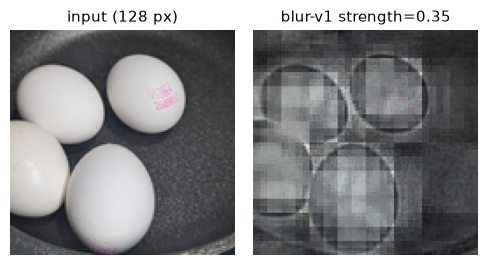

In [3]:
import requests

RAW_LOG, RAW_IN, RAW_OUT = DATA / "raw_api_transcript.json", DATA / "raw_demo_input.png", OUT / "raw_api_blur_result.png"
if not RAW_IN.exists():   # deterministic 128 px crop of the "before" photo
    Image.open(ROOT / "media/prep/A_sq.jpg").convert("RGB").crop((256, 256, 768, 768)).resize((128, 128), Image.LANCZOS).save(RAW_IN)

def redact(x):
    if isinstance(x, dict):
        return {k: "<redacted>" if k in ("owner", "user_id", "owner_id") else redact(v) for k, v in x.items()}
    if isinstance(x, list):
        return [redact(v) for v in x]
    if isinstance(x, str) and x.startswith("http") and "?" in x:
        host = x.split("/")[2]
        return f"https://{host}/<object path redacted>?<presigned query redacted>"
    return x

def raw_blur_demo(params={"strength": 0.35, "reach": 0.35}):
    base, H = client.base, {"Authorization": "Bearer " + _load_key()}   # header is never printed
    log, t0 = [], time.time()
    def call(method, path, **kw):
        r = requests.request(method, base + path, headers=H, timeout=60, **kw)
        body = r.json() if r.content and "json" in r.headers.get("content-type", "") else None
        log.append({"t": round(time.time() - t0, 2), "call": f"{method} /api/v1{path}", "status": r.status_code,
                    "response": redact(body)})
        r.raise_for_status()
        return body
    s = call("GET", "/engines/blur-v1")
    log[-1]["response"] = {k: s.get(k) for k in ("engine_id", "credits_per_run", "run_policy")}
    data = RAW_IN.read_bytes()
    a = call("POST", "/assets", json={"filename": RAW_IN.name, "content_type": "image/png", "size_bytes": len(data)})
    r = requests.put(a["upload"]["url"], data=data, headers=a["upload"].get("headers") or {}, timeout=120)
    log.append({"t": round(time.time() - t0, 2), "call": "PUT <presigned upload URL>", "status": r.status_code,
                "response": f"{len(data)} bytes"})
    call("POST", f"/assets/{a['asset_id']}/complete")
    job = call("POST", "/engines/blur-v1/process", json={"params": params, "input_files": {"image": a["asset_id"]}})
    job_id = job["job_id"]
    while True:
        st = call("GET", f"/jobs/{job_id}/status")
        if st["status"] in ("completed", "failed", "cancelled"):
            break
        time.sleep(3)
    if st["status"] != "completed":
        raise AtlasError(f"blur-v1 job {job_id}: {st}")
    for _ in range(10):
        r = requests.get(base + f"/jobs/{job_id}/result", headers=H, timeout=60)
        log.append({"t": round(time.time() - t0, 2), "call": f"GET /api/v1/jobs/{job_id}/result", "status": r.status_code,
                    "response": redact(r.json()) if r.status_code == 200 else None})
        if r.status_code == 200:
            break
        time.sleep(2)
    out = r.json()["outputs"][0]
    img = requests.get(out["url"], timeout=120)
    log.append({"t": round(time.time() - t0, 2), "call": "GET <presigned output URL>", "status": img.status_code,
                "response": f"{len(img.content)} bytes, {out.get('content_type')}"})
    RAW_OUT.write_bytes(img.content)
    return {"engine": "blur-v1", "params": params, "job_id": job_id, "asset_id": a["asset_id"], "log": log}

if MODE == "atlas" and (not RAW_LOG.exists() or os.environ.get("RAW_API_FORCE") == "1"):
    demo = raw_blur_demo()
    RAW_LOG.write_text(json.dumps(demo, indent=1), encoding="utf-8")
    ledger_add("2 raw API", "blur-v1", demo["job_id"], "raw-HTTP lifecycle demo (128 px crop)", "completed", 1)
demo = json.loads(RAW_LOG.read_text(encoding="utf-8"))
print(f"blur-v1 job {demo['job_id']}  params={demo['params']}\n")
for step in demo["log"]:
    resp = step["response"]
    resp = json.dumps(resp)[:160] + ("..." if len(json.dumps(resp)) > 160 else "") if resp is not None else ""
    print(f"{step['t']:6.2f}s  {step['status']}  {step['call']:<48} {resp}")

fig, ax = plt.subplots(1, 2, figsize=(5, 2.6))
for a_, im, title in zip(ax, [RAW_IN, RAW_OUT], ["input (128 px)", f"blur-v1 strength={demo['params']['strength']}"]):
    a_.imshow(Image.open(im)); a_.set_title(title); a_.axis("off")
plt.tight_layout(); plt.show()

### 2.3 The same thing through the `scrambled` client: caching and cost

`scrambled.client.AtlasClient` wraps that lifecycle. It adds:

* **A content-addressed cache.** Every job is keyed by `sha256(engine_id, params, input asset ids)`, and the record is stored at `cache/<engine>/<key>.json`. An identical call is free and needs no network. Uploads are deduplicated by file hash in `cache/assets.json`.
* **Replay mode.** No key and no network. A cache miss raises `ReplayMiss` instead of silently computing something else.
* **Resumable timeouts.** A job that outlives the local timeout is remembered in `cache/pending/`, and the next identical call resumes polling it instead of paying for a new one.
* **Retries.** 429 and 5xx responses are retried with backoff, `409` on a result is retried, and expired download URLs are re-signed.

Credits: `otoc-echo-v1`, `blur-v1`, `telablur-v1` and `tomography-api-v2` cost 1 credit per job and `retrocausal-echo-v1` costs 2. Cache hits cost 0.

In [4]:
P_SCR = otoc.OTOCParams()                                    # theta_x = 0.3pi, theta_zz = 0.35pi, 12 sites, depth 32, aer
P_CTL = dataclasses.replace(P_SCR, theta_zz=math.pi)          # Clifford control
for name, p in [("scrambling", P_SCR), ("control", P_CTL)]:
    key = cache_key(otoc.ENGINE, p.engine_params())
    path = client.cache / otoc.ENGINE / f"{key}.json"
    print(f"{name:10s} key {key}  ->  cache/{otoc.ENGINE}/{key}.json  ({'cached: free' if path.exists() else 'not cached: 1 credit'})")
print("\nengine params sent:", json.dumps(P_SCR.engine_params()))

scrambling key 51ed3c58046a5ff2  ->  cache/otoc-echo-v1/51ed3c58046a5ff2.json  (cached: free)
control    key e8f29f205d89ffeb  ->  cache/otoc-echo-v1/e8f29f205d89ffeb.json  (cached: free)

engine params sent: {"depth": 32, "n_sites": 12, "min_tap_level": 0, "include_taps": true, "machine": "aer", "exact": true, "disorder": 0, "lattice": "chain", "kick": "Z", "theta_x": 0.9424777960769379, "theta_z": 0, "theta_zz": 1.0995574287564276, "via": "direct"}


## 3. Measure: `otoc-echo-v1`, scrambling run and Clifford control

These are the two measurements the rest of the project is built on (jobs `8df5cfa2…` and `89c7f269…`). Both ran on Atlas with `machine: aer, exact: true`, which is the exact, noiseless emulator.

scrambling job 8df5cfa2-e57c-43a8-a93a-63975efd252c  measured on Moth Atlas, otoc-echo-v1 (aer emulator)
           light-cone arrival step per site: [6, 5, 4, 3, 2, 1, 1, 1, 2, 3, 4, 5]
           late-time (t=17..32) mean |F| off the kick site: 0.253
control    job 89c7f269-9a0c-473a-936d-a0ac2a08aa77  measured on Moth Atlas, otoc-echo-v1 (aer emulator)
           light-cone arrival step per site: [None, None, None, None, None, None, 1, None, None, None, None, None]
           late-time (t=17..32) mean |F| off the kick site: 1.0

control: max | |F| - 1 | = 2.220446049250313e-16   F on the kick site: [-1.]


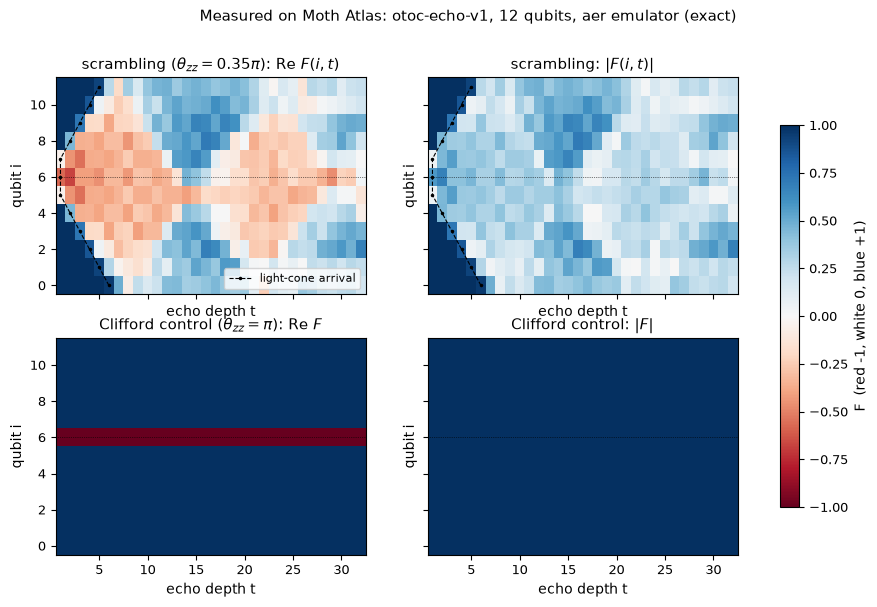

In [5]:
n0 = len(client.jobs)
scr = otoc.measure(P_SCR, mode=MODE, client=client)
ctl = otoc.measure(P_CTL, mode=MODE, client=client)
ledger_new_since(n0, "3 measure", "scrambling run / Clifford control")
for name, m in [("scrambling", scr), ("control", ctl)]:
    s = m.summary()
    print(f"{name:10s} job {m.job_id}  {m.label}")
    print(f"           light-cone arrival step per site: {s['light_cone_arrival_t']}")
    print(f"           late-time (t=17..32) mean |F| off the kick site: {s['late_mean_absF_offkick']}")
print("\ncontrol: max | |F| - 1 | =", float(np.abs(np.abs(ctl.F) - 1).max()),
      "  F on the kick site:", np.unique(np.round(ctl.F[ctl.kick_site].real, 12)))

def heat(ax, Z, title, vmin=-1, vmax=1, kick=6):
    T = Z.shape[1]
    im = ax.imshow(Z, cmap=CMAP, vmin=vmin, vmax=vmax, aspect="auto", origin="lower",
                   extent=[0.5, T + 0.5, -0.5, Z.shape[0] - 0.5], interpolation="nearest")
    ax.axhline(kick, color="k", lw=0.5, ls=":")
    ax.set_title(title); ax.set_xlabel("echo depth t"); ax.set_ylabel("qubit i")
    return im

fig, ax = plt.subplots(2, 2, figsize=(11, 6.2), sharex=True, sharey=True)
heat(ax[0, 0], scr.F.real, r"scrambling ($\theta_{zz}=0.35\pi$): Re $F(i,t)$")
im = heat(ax[0, 1], np.abs(scr.F), r"scrambling: $|F(i,t)|$")
heat(ax[1, 0], ctl.F.real, r"Clifford control ($\theta_{zz}=\pi$): Re $F$")
heat(ax[1, 1], np.abs(ctl.F), r"Clifford control: $|F|$")
arr = otoc.arrival_steps(scr.F)
for a_ in ax[0]:
    a_.plot([t for t in arr if t], [i for i, t in enumerate(arr) if t], "k.--", lw=0.8, ms=3, label="light-cone arrival")
ax[0, 0].legend(loc="lower right", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="F  (red -1, white 0, blue +1)")
fig.suptitle("Measured on Moth Atlas: otoc-echo-v1, 12 qubits, aer emulator (exact)", y=0.99)
plt.show()

The scrambling run shows a light cone that reaches one more site per echo step on each side. Inside it, $|F|$ falls towards a small value, recovers partly around $t \approx 13$ to $16$ (finite-size revival), and decays again. In the control the kick flips its own qubit ($F = -1$) and nothing else ever changes: no light cone and no loss of memory.

## 4. Verify: an independent classical simulation matches Atlas

`scrambled.otoc.simulate` is an exact statevector implementation of the same circuit, written from the physics above ($2^{12} = 4096$ amplitudes, so this is easy on a laptop). If it reproduces the engine output to rounding error, we know exactly what the engine computes, including its gate ordering, normalisation and qubit indexing. That is what makes the media mapping physically meaningful.

max |F_atlas - F_classical|: scrambling 5.07e-14, control 2.78e-14


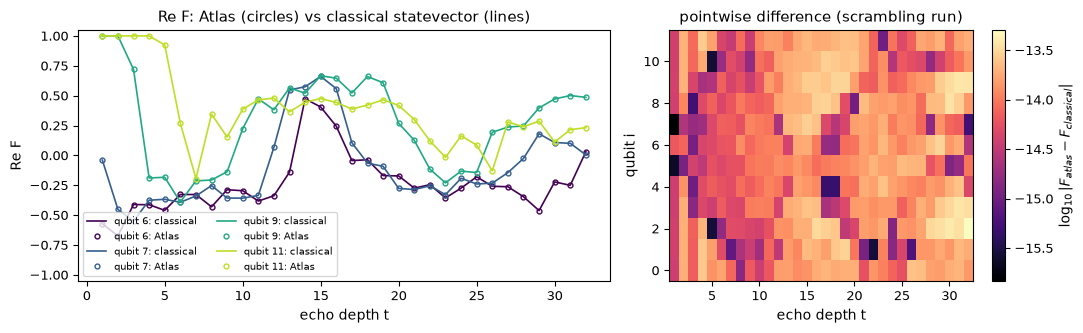

In [6]:
sim_scr, sim_ctl = otoc.simulate(P_SCR), otoc.simulate(P_CTL)
d_scr, d_ctl = np.abs(sim_scr.F - scr.F), np.abs(sim_ctl.F - ctl.F)
print(f"max |F_atlas - F_classical|: scrambling {d_scr.max():.2e}, control {d_ctl.max():.2e}")
assert d_scr.max() < 1e-8 and d_ctl.max() < 1e-8

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [1.4, 1]})
t = np.arange(1, scr.depth + 1)
colors = plt.get_cmap("viridis")(np.linspace(0, 0.9, 4))
for c, i in zip(colors, [6, 7, 9, 11]):
    ax[0].plot(t, sim_scr.F[i].real, "-", color=c, lw=1.2, label=f"qubit {i}: classical")
    ax[0].plot(t, scr.F[i].real, "o", color=c, ms=3.5, mfc="none", label=f"qubit {i}: Atlas")
ax[0].set_xlabel("echo depth t"); ax[0].set_ylabel("Re F"); ax[0].set_ylim(-1.05, 1.05)
ax[0].set_title("Re F: Atlas (circles) vs classical statevector (lines)")
ax[0].legend(ncol=2, fontsize=7, loc="lower left")
im = ax[1].imshow(np.log10(d_scr + 1e-18), aspect="auto", origin="lower", cmap="magma",
                  extent=[0.5, scr.depth + 0.5, -0.5, 11.5])
fig.colorbar(im, ax=ax[1], label=r"$\log_{10}|F_{atlas}-F_{classical}|$")
ax[1].set_title("pointwise difference (scrambling run)"); ax[1].set_xlabel("echo depth t"); ax[1].set_ylabel("qubit i")
plt.tight_layout(); plt.show()

## 5. New physics: switching scrambling on and off with $\theta_{zz}$

The two runs above are the two extremes. Between them sits a family of circuits. The sweep keeps $\theta_x = 0.3\pi$ and the 12-site chain fixed and varies the coupling angle:

$$\theta_{zz}/\pi \in \{1.0,\ 0.95,\ 0.9,\ 0.8,\ 0.7,\ 0.6,\ 0.5,\ 0.35,\ 0.25,\ 0\}.$$

That is 10 `otoc-echo-v1` runs: 7 new for this notebook and 3 re-used from the cache. The two ends are non-scrambling for different reasons. At $\pi$ the gate is a Pauli (the Clifford control), and at $0$ there is no coupling. Close to $\pi$ the effective interaction is weak (it scales with $\pi - \theta_{zz}$), so scrambling should switch on *gradually*, with a slower and shallower decay of $|F|$.

| θzz/π | Atlas job | sites reached by kick | late mean abs(F) (t=17..32) | min of mean abs(F) | max abs(Atlas − classical) |
|---|---|---|---|---|---|
| 1.00 | `89c7f269` | 1 | 1.000 | 1.000 | 2.8e-14 |
| 0.95 | `af384d74` | 12 | 0.820 | 0.798 | 3.0e-14 |
| 0.90 | `98c918e3` | 12 | 0.682 | 0.659 | 4.1e-14 |
| 0.80 | `81f948b4` | 12 | 0.353 | 0.229 | 3.4e-14 |
| 0.70 | `f9c7c3c5` | 12 | 0.435 | 0.233 | 5.2e-14 |
| 0.60 | `22c9fe47` | 12 | 0.378 | 0.243 | 2.3e-14 |
| 0.50 | `590faf7f` | 12 | 0.365 | 0.197 | 3.7e-14 |
| 0.35 | `8df5cfa2` | 12 | 0.253 | 0.161 | 5.1e-14 |
| 0.25 | `253a55d0` | 12 | 0.442 | 0.124 | 2.2e-14 |
| 0.00 | `130a446c` | 1 | 1.000 | 1.000 | 3.6e-14 |

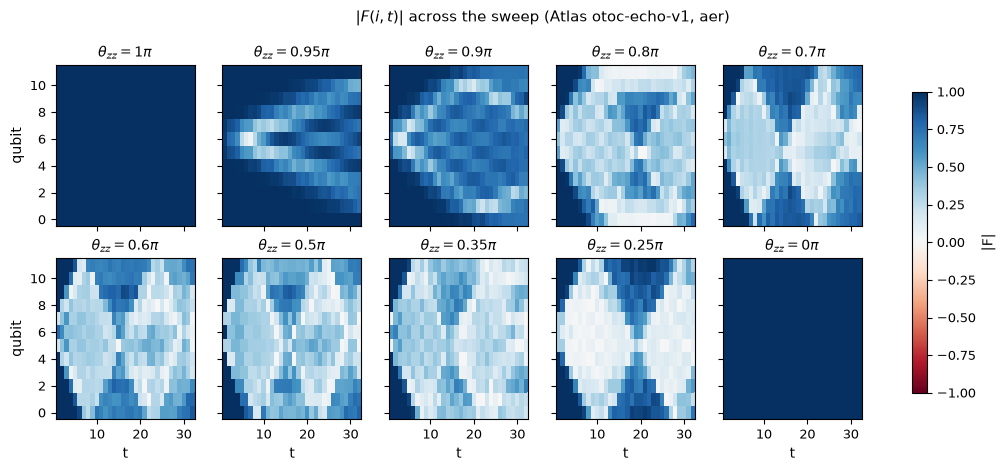

In [7]:
SWEEP = [1.0, 0.95, 0.9, 0.8, 0.7, 0.6, 0.5, 0.35, 0.25, 0.0]
n0 = len(client.jobs)
sweep = {v: otoc.measure(dataclasses.replace(P_SCR, theta_zz=v * math.pi), mode=MODE, client=client) for v in SWEEP}
ledger_new_since(n0, "5 sweep", "theta_zz sweep point")

def offkick_mean(F, k=6):
    return np.delete(np.abs(F), k, axis=0).mean(axis=0)

rows = []
for v, m in sweep.items():
    sim = otoc.simulate(dataclasses.replace(P_SCR, theta_zz=v * math.pi))
    arr = otoc.arrival_steps(m.F)
    reach = sum(a is not None for a in arr)
    rows.append([f"{v:.2f}", f"`{m.job_id[:8]}`", reach, f"{offkick_mean(m.F)[16:].mean():.3f}",
                 f"{offkick_mean(m.F).min():.3f}", f"{np.abs(sim.F - m.F).max():.1e}"])
md_table([r"θzz/π", "Atlas job", "sites reached by kick", "late mean abs(F) (t=17..32)", "min of mean abs(F)",
          "max abs(Atlas − classical)"], rows)

fig, ax = plt.subplots(2, 5, figsize=(13, 4.6), sharex=True, sharey=True)
for a_, (v, m) in zip(ax.flat, sweep.items()):
    im = a_.imshow(np.abs(m.F), cmap=CMAP, vmin=-1, vmax=1, aspect="auto", origin="lower",
                   extent=[0.5, 32.5, -0.5, 11.5], interpolation="nearest")
    a_.set_title(rf"$\theta_{{zz}}={v:g}\pi$", fontsize=10)
for a_ in ax[1]: a_.set_xlabel("t")
for a_ in ax[:, 0]: a_.set_ylabel("qubit")
fig.colorbar(im, ax=ax, shrink=0.85, label="|F|")
fig.suptitle(r"$|F(i,t)|$ across the sweep (Atlas otoc-echo-v1, aer)", y=1.0)
plt.show()

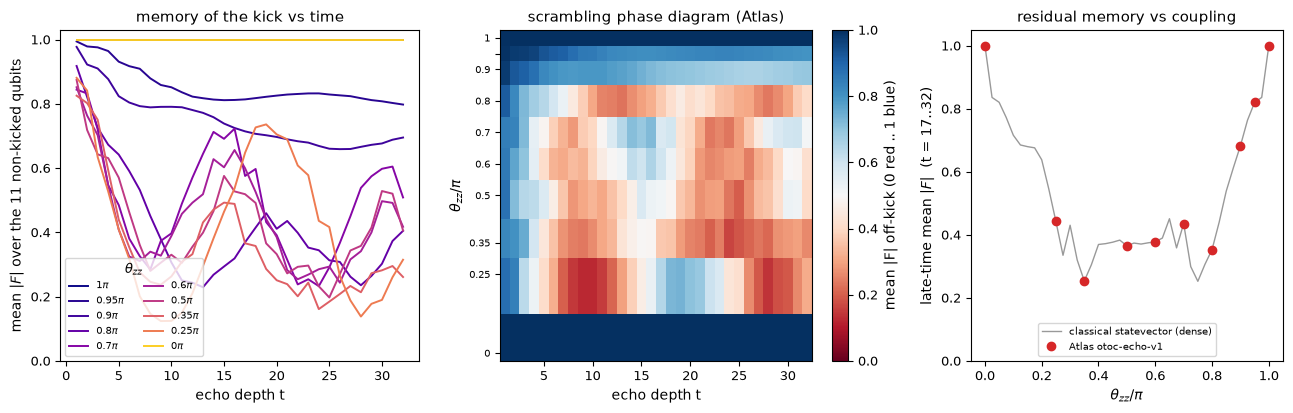

saved notebook\out\theta_zz_sweep.png


In [8]:
# Dense classical curve (labelled classical) behind the 10 Atlas points
dense = np.linspace(0, 1, 41)
dense_late = [offkick_mean(otoc.simulate(dataclasses.replace(P_SCR, theta_zz=v * math.pi)).F)[16:].mean() for v in dense]

fig = plt.figure(figsize=(13, 4.2))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.25, 1])
ax0, ax1, ax2 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
cm = plt.get_cmap("plasma")
t = np.arange(1, 33)
for v, m in sweep.items():
    ax0.plot(t, offkick_mean(m.F), color=cm(0.9 * (1 - v)), lw=1.4, label=rf"{v:g}$\pi$")
ax0.set_xlabel("echo depth t"); ax0.set_ylabel(r"mean $|F|$ over the 11 non-kicked qubits"); ax0.set_ylim(0, 1.03)
ax0.set_title("memory of the kick vs time"); ax0.legend(title=r"$\theta_{zz}$", fontsize=7, ncol=2)

vals = np.array(sorted(SWEEP))
Z = np.array([offkick_mean(sweep[v].F) for v in vals])
edges = np.concatenate([[vals[0] - 0.025], (vals[1:] + vals[:-1]) / 2, [vals[-1] + 0.025]])
pm = ax1.pcolormesh(np.arange(0.5, 33.5), edges, Z, cmap=CMAP, vmin=0, vmax=1, shading="flat")
ax1.set_yticks(vals); ax1.set_yticklabels([f"{v:g}" if v != 0.95 else "" for v in vals], fontsize=7)
ax1.set_xlabel("echo depth t"); ax1.set_ylabel(r"$\theta_{zz}/\pi$")
ax1.set_title("scrambling phase diagram (Atlas)")
fig.colorbar(pm, ax=ax1, label="mean |F| off-kick (0 red .. 1 blue)")

ax2.plot(dense, dense_late, "-", color="0.6", lw=1, label="classical statevector (dense)")
ax2.plot(SWEEP, [offkick_mean(sweep[v].F)[16:].mean() for v in SWEEP], "o", color="C3", ms=6, label="Atlas otoc-echo-v1")
ax2.set_xlabel(r"$\theta_{zz}/\pi$"); ax2.set_ylabel(r"late-time mean $|F|$  (t = 17..32)"); ax2.set_ylim(0, 1.05)
ax2.set_title("residual memory vs coupling"); ax2.legend(fontsize=7, loc="lower center")
plt.tight_layout()
fig.savefig(OUT / "theta_zz_sweep.png", dpi=130)
plt.show()
print("saved", (OUT / "theta_zz_sweep.png").relative_to(ROOT))

**Reading the sweep.**

* At $\theta_{zz} = \pi$ and at $\theta_{zz} = 0$ the residual memory is exactly 1. The kick never leaves its own qubit (the "sites reached" column shows 1).
* At $0.95\pi$ the light cone still opens across the whole chain, because any coupling spreads the operator. But $|F|$ decays slowly and stays high: about 0.82 at late times, against 0.68 at $0.9\pi$.
* From $0.8\pi$ down to $0.25\pi$ the chain scrambles strongly. The mean memory dips to between 0.12 and 0.24, and the late-time average sits between 0.25 and 0.44. It is not monotonic in $\theta_{zz}$, because the finite-size revivals shift with the coupling. The dense classical curve shows that structure between the Atlas points.

**Caveats, stated precisely.**

* This is a 12-qubit system, so the plot shows a *crossover*, not a sharp thermodynamic phase transition. "Phase diagram" is meant in the sense of a map of where scrambling switches on.
* A clean kicked Ising chain with only a transverse field ($\theta_z = 0$, no disorder) maps to free fermions, so it is integrable. The decay of $|F|$ for a $Z$ kick reflects the operator spreading as a non-local (Jordan-Wigner string) object, not chaos. The engine's `theta_z` and `disorder` parameters break integrability. They are not swept here.
* Every Atlas point agrees with the classical simulation to about $10^{-13}$. The dense grey curve is classical and is labelled as such.

## 6. From $F$ to images: quantum image ladders and the strip mapping

The media mapping cuts a picture into **one vertical strip per qubit** (12 strips) and lets media time run along echo depth $t$. At each moment, strip $i$ reads $F(i,t)$:

| measured | visual |
|---|---|
| $|F|$ (memory) | 1 = sharp. Lower values blur the strip along the `blur-v1` ladder, where the reach grows with strength, so the blur also becomes less local. |
| Re $F < 0$ (polarity) | the strip is shown upside down: it sees the kick as a flip |
| scramble progress $= g \int_1^t (1-|F|)\,dt'$ | past a threshold the strip morphs along the `telablur-v1` ladder from photo A (whole eggs) to photo B (scrambled eggs) |
| outside the light cone ($F = 1$ exactly) | untouched pixels |

The ladders are rendered once per image on Atlas: `blur-v1` at strengths 0.1 to 0.4 and `telablur-v1` (A towards B) at 0.02, 0.5, 0.9 and 0.98, which is 8 jobs. Each frame is then a classical per-strip crossfade between those quantum renders.

ladder jobs:
  blur-v1 {'strength': 0.1, 'reach': 0.1} 37894b70
  blur-v1 {'strength': 0.2, 'reach': 0.2} e3b9ba8e
  blur-v1 {'strength': 0.3, 'reach': 0.3} df5be01b
  blur-v1 {'strength': 0.4, 'reach': 0.4} 94b48e49
  telablur-v1 {'strength': 0.02} 0cc32be5
  telablur-v1 {'strength': 0.5} d5fe1183
  telablur-v1 {'strength': 0.9} e705a08b
  telablur-v1 {'strength': 0.98} a58d98ba


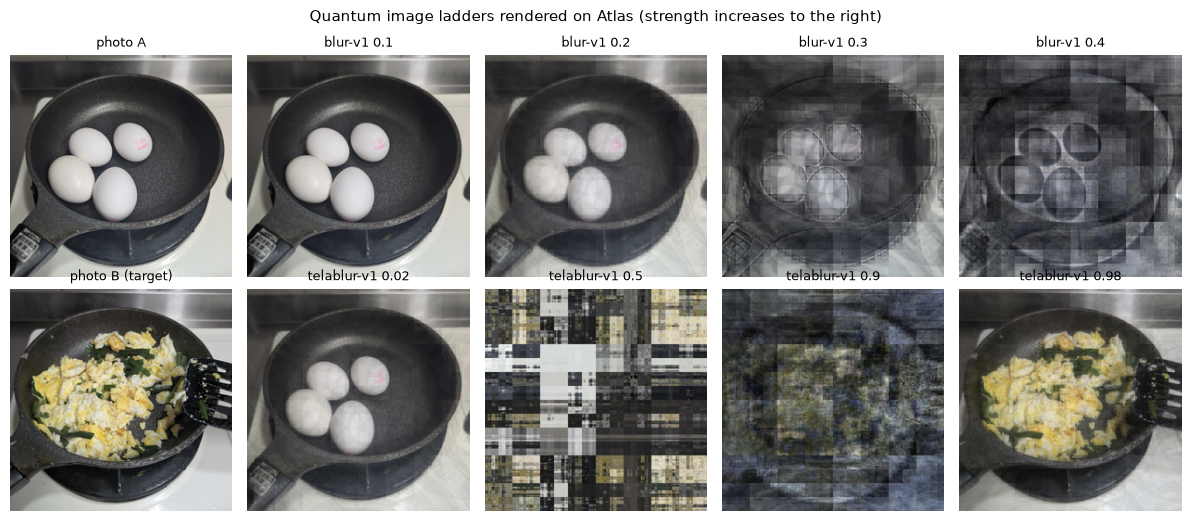

In [9]:
A, B = ROOT / "media/prep/A_sq.jpg", ROOT / "media/prep/B_sq.jpg"
n0 = len(client.jobs)
lad = image.atlas_ladders(client, A, B, log=print)
ledger_new_since(n0, "6 image", "egg photo ladder rung")
print("ladder jobs:", *[f"{e} {p} {j[:8]}" for e, p, j in lad.jobs], sep="\n  ")

imgA, imgB = image.load_rgb(A, (1024, 1024)), image.load_rgb(B, (1024, 1024))
fig, ax = plt.subplots(2, 5, figsize=(12, 5.2))
row0 = [("photo A", imgA)] + [(f"blur-v1 {s}", L) for s, L in zip(image.BLUR_LEVELS, lad.blur)]
row1 = [("photo B (target)", imgB)] + [(f"telablur-v1 {s}", M) for s, M in zip(image.MORPH_LEVELS, lad.morph)]
for a_, (title, im) in zip(list(ax[0]) + list(ax[1]), row0 + row1):
    a_.imshow(thumb(im, 240)); a_.set_title(title, fontsize=9); a_.axis("off")
fig.suptitle("Quantum image ladders rendered on Atlas (strength increases to the right)", y=0.99)
plt.tight_layout(); plt.show()

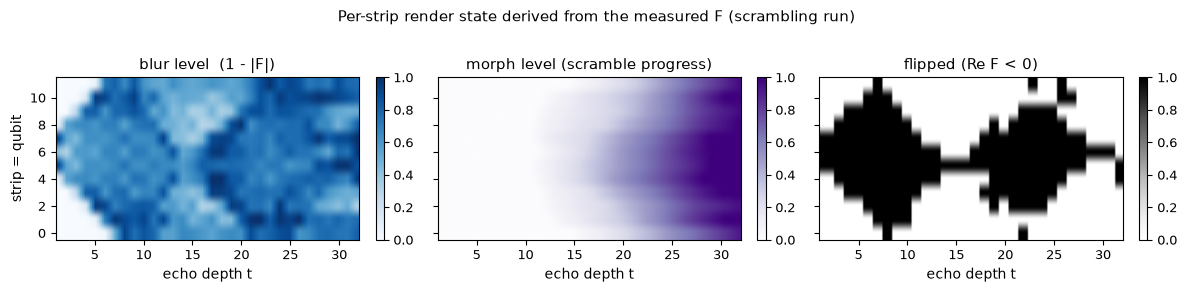

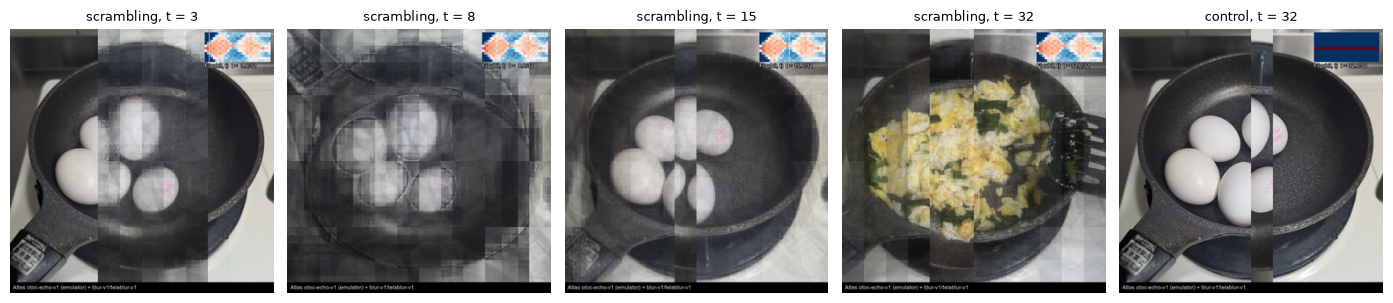

full-resolution frames saved in notebook/out/eggs_*.png


In [10]:
T = scr.depth
ts = np.linspace(1, T, 125)
states = [mapping.strip_states(scr.F, x) for x in ts]
blur = np.array([[s.blur for s in st] for st in states]).T
morph = np.array([[s.morph for s in st] for st in states]).T
flip = np.array([[s.flipped for s in st] for st in states]).T.astype(float)
fig, ax = plt.subplots(1, 3, figsize=(12, 2.8), sharey=True)
for a_, Z, title, cmap in [(ax[0], blur, "blur level  (1 - |F|)", "Blues"), (ax[1], morph, "morph level (scramble progress)", "Purples"),
                           (ax[2], flip, "flipped (Re F < 0)", "Greys")]:
    im = a_.imshow(Z, aspect="auto", origin="lower", cmap=cmap, vmin=0, vmax=1, extent=[1, T, -0.5, 11.5])
    a_.set_title(title); a_.set_xlabel("echo depth t")
    fig.colorbar(im, ax=a_, fraction=0.05)
ax[0].set_ylabel("strip = qubit")
fig.suptitle("Per-strip render state derived from the measured F (scrambling run)", y=1.02)
plt.tight_layout(); plt.show()

label_q = "Atlas otoc-echo-v1 (emulator) + blur-v1/telablur-v1"
frames = []
for name, m, tt in [("scrambling", scr, 3), ("scrambling", scr, 8), ("scrambling", scr, 15), ("scrambling", scr, 32), ("control", ctl, 32)]:
    fr = image.overlay(image.compose(imgA, lad, mapping.strip_states(m.F, tt)), m.F, tt, label_q)
    p = OUT / f"eggs_{name}_t{tt:02d}.png"
    Image.fromarray(fr).save(p)
    frames.append((f"{name}, t = {tt}", fr))
fig, ax = plt.subplots(1, 5, figsize=(14, 3.2))
for a_, (title, fr) in zip(ax, frames):
    a_.imshow(thumb(fr, 300)); a_.set_title(title, fontsize=9); a_.axis("off")
plt.tight_layout(); plt.show()
print("full-resolution frames saved in notebook/out/eggs_*.png")

notebook\out\eggs_scrambling.mp4 (2.8 MB), preview 909 kB


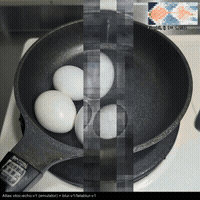

In [11]:
# 6 s animation t = 1..32 (full-res MP4 in notebook/out, small GIF preview inline)
anim = image.scramble_image(A, OUT / "eggs_scrambling.mp4", scr, lad, seconds=6, fps=24, label=label_q)
gif = OUT / "eggs_scrambling_preview.gif"
subprocess.run(["ffmpeg", "-v", "error", "-y", "-i", str(anim), "-vf",
                "fps=8,scale=200:-2:flags=lanczos,split[a][b];[a]palettegen=max_colors=96[p];[b][p]paletteuse=dither=bayer",
                str(gif)], check=True)
print(f"{anim.relative_to(ROOT)} ({anim.stat().st_size/1e6:.1f} MB), preview {gif.stat().st_size/1e3:.0f} kB")
display(IPImage(filename=str(gif)))

## 7. From $F$ to audio: the measured taps as an echo

The same map works as a **multi-tap delay line**. This mirrors the tap map that Atlas's `retrocausal-echo-v1` documents. Every cell $(i,t)$ is one echo tap:

* depth $t$ sets the delay: $t \cdot 6.4\,\text{s}/32$
* $|F|$ sets the level
* the qubit position sets the stereo pan (left to right along the chain)
* Re $F<0$ inverts the polarity

Outside the light cone the taps stay at full level. Inside it they decay and scatter, so the echo is an audible picture of how far the kick has spread.

**Renderer.** This notebook renders the audio **locally with numpy**, a classical convolution of the measured taps, and labels it that way. Below we also try Atlas's own `retrocausal-echo-v1` once, with a timeout, and record what happened.

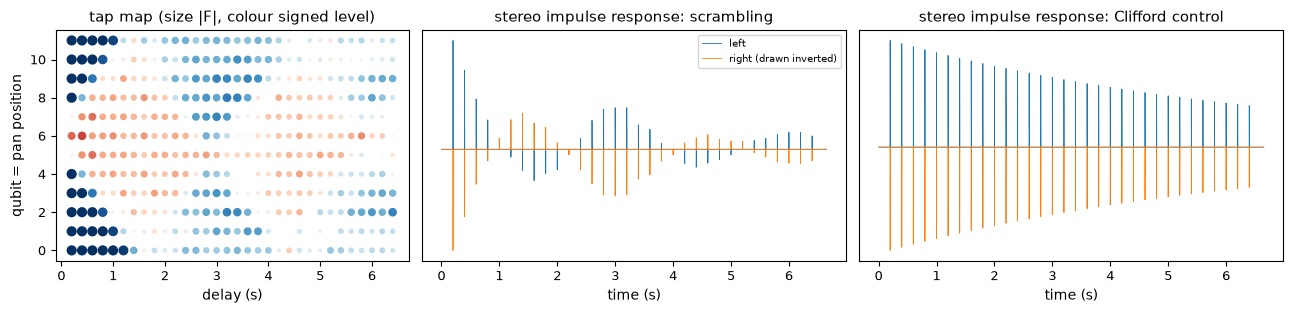

notebook/out/echo_scrambling.wav: 26.6 s stereo, local numpy tap render (classical DSP)


**scrambling** echo (8 s preview, cooking audio + OTOC echo):

notebook/out/echo_control.wav: 26.6 s stereo, local numpy tap render (classical DSP)


**control** echo (8 s preview, cooking audio + OTOC echo):

In [12]:
def impulse_response(F, sr=8000, seconds=7.0):
    x = np.zeros(int(sr * 0.05)); x[0] = 1.0
    return audio.render_taps(x, sr, F, mix=1.0, tail=True)[: int(sr * seconds)]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2), gridspec_kw={"width_ratios": [1, 1.2, 1.2]})
taps = np.array(audio.taps_from_F(scr.F))
sc = ax[0].scatter(taps[:, 1] * 6.4 / 32, taps[:, 0], s=40 * taps[:, 2], c=taps[:, 3] * taps[:, 2], cmap=CMAP, vmin=-1, vmax=1)
ax[0].set_xlabel("delay (s)"); ax[0].set_ylabel("qubit = pan position"); ax[0].set_title("tap map (size |F|, colour signed level)")
for a_, (name, m) in zip(ax[1:], [("scrambling", scr), ("Clifford control", ctl)]):
    ir = impulse_response(m.F)
    tt = np.arange(len(ir)) / 8000
    a_.plot(tt, ir[:, 0], lw=0.6, label="left"); a_.plot(tt, -ir[:, 1], lw=0.6, label="right (drawn inverted)")
    a_.set_title(f"stereo impulse response: {name}"); a_.set_xlabel("time (s)"); a_.set_yticks([])
ax[1].legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()

dry, sr = audio.read_mono(ROOT / "media/prep/stem_20s.wav")
import soundfile as sf
for name, m in [("scrambling", scr), ("control", ctl)]:
    wet = audio.render_taps(dry, sr, m.F)
    sf.write(OUT / f"echo_{name}.wav", wet, sr, subtype="PCM_16")
    print(f"notebook/out/echo_{name}.wav: {len(wet)/sr:.1f} s stereo, local numpy tap render (classical DSP)")
    seg = wet[: int(sr * 8)][::2]                      # 8 s preview at 24 kHz, embedded below
    display(Markdown(f"**{name}** echo (8 s preview, cooking audio + OTOC echo):"))
    display(Audio(seg.T, rate=sr // 2))

In [13]:
RETRO_LOG = DATA / "retrocausal_attempt.json"
retro_wav = DATA / "stem_6s_mono.wav"
if not retro_wav.exists():
    sf.write(retro_wav, dry[: sr * 6], sr, subtype="PCM_16")
attempts = json.loads(RETRO_LOG.read_text(encoding="utf-8")) if RETRO_LOG.exists() else []

def try_retro(timeout):
    t0 = time.time()
    try:
        path, job = audio.render_engine(client, retro_wav, scr.params, OUT / "retrocausal_echo.wav", timeout=timeout)
        return {"outcome": "completed", "job_id": job, "seconds": round(time.time() - t0, 1)}
    except JobTimeout as e:
        return {"outcome": f"still running after the {timeout:.0f} s local timeout (kept in cache/pending; resumed on the next atlas run)",
                "job_id": e.job_id, "seconds": round(time.time() - t0, 1)}
    except AtlasError as e:
        jid = re.search(r"[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}", str(e))
        return {"outcome": "failed: " + str(e).split(": ", 1)[-1][:200], "job_id": jid.group(0) if jid else None,
                "seconds": round(time.time() - t0, 1)}

retro_job = None
try:   # cache-only lookup (a replay client never submits): free, and works without a key
    _, retro_job = audio.render_engine(AtlasClient(mode="replay", cache_dir=client.cache), retro_wav, scr.params,
                                       OUT / "retrocausal_echo.wav")
except (ReplayMiss, AtlasError):
    pass
if retro_job:
    client.jobs.append((audio.ENGINE, retro_job, True))
if retro_job is None and MODE == "atlas":
    res = {"when": time.strftime("%Y-%m-%d %H:%M %z"), **try_retro(timeout=240)}
    attempts.append(res)
    RETRO_LOG.write_text(json.dumps(attempts, indent=1), encoding="utf-8")
    ledger_add("7 audio", "retrocausal-echo-v1", res["job_id"], "6 s cooking audio through the measured map",
               res["outcome"].split(" (")[0], 2 if res["outcome"] == "completed" else None)
    retro_job = res["job_id"] if res["outcome"] == "completed" else None

md_table(["when", "job id", "outcome", "wall time (s)"],
         [["2026-10-03 (earlier project run)", "`6dabddfc-5ba3-4281-be12-c1d8e1303b72`", "failed: engine_timeout (server side)", ""]]
         + [[a["when"], f"`{a['job_id']}`" if a["job_id"] else "", a["outcome"], a["seconds"]]
            for a in {a["job_id"]: a for a in attempts}.values()])   # latest status per job
if retro_job:
    x, r = sf.read(OUT / "retrocausal_echo.wav", always_2d=True)
    print(f"retrocausal-echo-v1 job {retro_job} completed: {len(x)/r:.1f} s, {x.shape[1]} channel(s), {r} Hz "
          "(echo rendered server-side by Atlas from its own OTOC measurement)")
    display(Audio(x.T[:, ::2], rate=r // 2))
else:
    print("No retrocausal-echo-v1 result is available, so the project's soundtracks use the local tap render above (labelled classical).")

| when | job id | outcome | wall time (s) |
|---|---|---|---|
| 2026-10-03 (earlier project run) | `6dabddfc-5ba3-4281-be12-c1d8e1303b72` | failed: engine_timeout (server side) |  |
| 2026-10-04 04:26 +0800 | `721c5d5d-6400-431d-b21c-4b5f84d1c7bc` | still processing about 70 min after submission (server status: waiting on aer); left pending in cache/pending, resumed by the next atlas run | 3009 |

No retrocausal-echo-v1 result is available, so the project's soundtracks use the local tap render above (labelled classical).


## 8. From $F$ to video: `scrambled.video` on a cooking clip

`scramble_video` applies the same strip mapping to every frame, with media time running along echo depth. Quantum ladders for every frame would cost one job per rung per frame, which is thousands of credits. Instead the ladders are rendered on $K$ keyframes and crossfaded in time. Level 0 of every ladder is the live frame, so strips outside the light cone play the original video. Here the excerpt is 8 s (from 26 s, when the stirring starts), with $K = 2$ keyframes at 360 px. That is $2 \times (3\ \text{blur-v1} + 3\ \text{telablur-v1}) = 12$ jobs, and the morph target is the excerpt's own last frame. The soundtrack is the cooking audio plus the local OTOC echo.

keyframe 1/2 at 28.00s: ladders ready (atlas)


keyframe 2/2 at 32.00s: ladders ready (atlas)


notebook\out\eggs_excerpt_scrambled.mp4: 240 frames [204, 360] @ 30 fps, 12 ladder jobs, audio: local numpy tap render of the OTOC map (classical DSP)


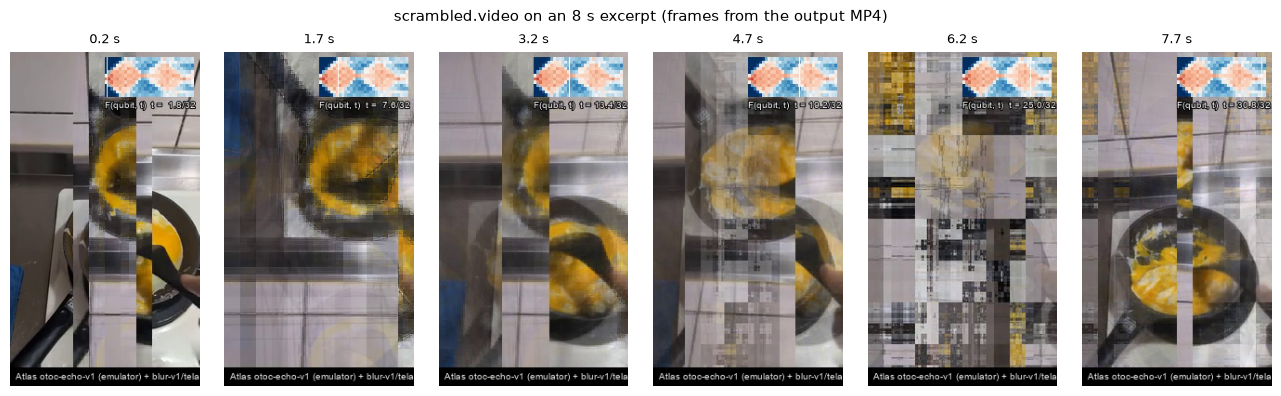

preview GIF (1124 kB); full MP4 with sound: notebook/out/eggs_excerpt_scrambled.mp4


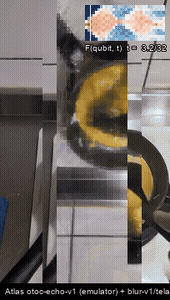

In [14]:
VID_OUT, VID_GIF = OUT / "eggs_excerpt_scrambled.mp4", OUT / "eggs_excerpt_preview.gif"
n0 = len(client.jobs)
try:
    rep = video.scramble_video(ROOT / "media/clip_720.mp4", VID_OUT, scr, mode=MODE, client=client, start=26.0, duration=8.0,
                               keyframes=2, max_side=360, audio_src=ROOT / "media/stem_full.wav", label=label_q, log=print)
    (OUT / "eggs_excerpt_scrambled.json").write_text(json.dumps(rep, indent=1), encoding="utf-8")
    ledger_new_since(n0, "8 video", "keyframe ladder rung (8 s excerpt, 360 px)")
    print(f"{VID_OUT.relative_to(ROOT)}: {rep['frames']} frames {rep['size']} @ {rep['fps']:.0f} fps, "
          f"{len(rep['jobs'])} ladder jobs, audio: {rep.get('audio')}")
    subprocess.run(["ffmpeg", "-v", "error", "-y", "-ss", "0.5", "-t", "7", "-i", str(VID_OUT), "-vf",
                    "fps=7,scale=170:-2:flags=lanczos,split[a][b];[a]palettegen=max_colors=96[p];[b][p]paletteuse=dither=bayer",
                    str(VID_GIF)], check=True)
except (ReplayMiss, RuntimeError) as e:
    print("video render skipped:", str(e)[:200], "\n(showing the saved preview instead)")
    rep = json.loads((OUT / "eggs_excerpt_scrambled.json").read_text(encoding="utf-8")) if (OUT / "eggs_excerpt_scrambled.json").exists() else None

if VID_OUT.exists():
    info = ffmpeg.probe(VID_OUT)
    fig, ax = plt.subplots(1, 6, figsize=(13, 3.9))
    for a_, tt in zip(ax, np.linspace(0.2, info.duration - 0.3, 6)):
        a_.imshow(ffmpeg.frame_at(VID_OUT, tt, info.width, info.height)); a_.set_title(f"{tt:.1f} s", fontsize=9); a_.axis("off")
    fig.suptitle("scrambled.video on an 8 s excerpt (frames from the output MP4)", y=1.0)
    plt.tight_layout(); plt.show()
if VID_GIF.exists():
    print(f"preview GIF ({VID_GIF.stat().st_size/1e3:.0f} kB); full MP4 with sound: notebook/out/{VID_OUT.name}")
    display(IPImage(filename=str(VID_GIF)))

## 9. Another view of scrambling: tomography of the echo circuit (`tomography-api-v2`)

The OTOC can also be read from **state tomography**. Because the un-kicked echo returns to $|{+}\rangle^{\otimes n}$, $F(i,t)$ is just the single-qubit Bloch vector component $\langle X_i\rangle + i\langle Y_i\rangle$ of the *echoed state* $U^{-t} Z_k U^{t}|{+}\rangle^{\otimes n}$. A tomography engine that takes an arbitrary circuit can therefore measure the same quantity a second way, from shots. It can also measure what $F$ cannot show directly: where the information went. Single-qubit purity falls towards the maximally mixed value of 1/2, and two-qubit **mutual information** appears between pairs as the light cone reaches them, for example $I(3{:}9)$ at $t \approx 3$ to $4$. The kick's information has moved into correlations.

`tomography-api-v2` takes an OpenQASM 2 circuit. Below the gate list is built once and used twice: exported as QASM for Atlas, and simulated with numpy to (a) check that the circuit really is the `otoc-echo-v1` circuit (it must reproduce the Atlas $F$) and (b) predict the tomography signal (labelled classical).

QASM-gate-list simulation vs Atlas otoc-echo-v1 (t = 1..12): max |dF| = 2.8e-14
echo circuit at t = 4: 197 gates, 88 rzz; first lines:
OPENQASM 2.0;
include "qelib1.inc";
qreg q[12];
h q[0];
h q[1];
h q[2];
...


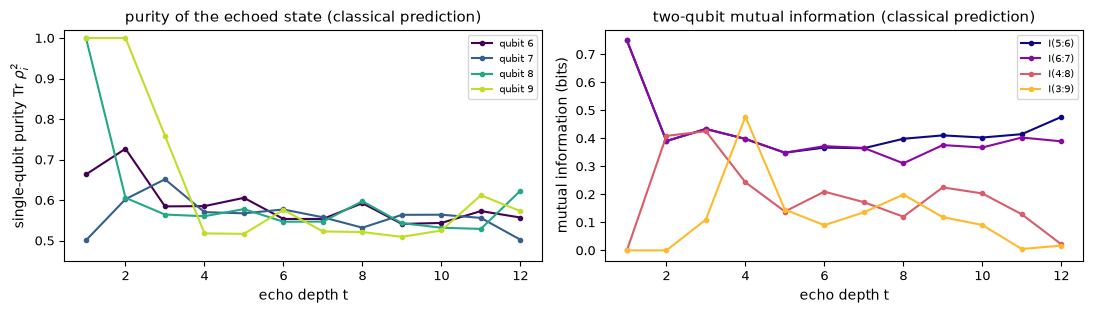

In [15]:
def echo_gates(t, p=P_SCR):
    n, k = p.n_sites, p.resolved_kick_site
    g = [("h", (q,), None) for q in range(n)]
    fwd = [("rzz", (q, q + 1), p.theta_zz) for q in range(n - 1)] + [("rx", (q,), p.theta_x) for q in range(n)]
    bwd = [("rx", (q,), -p.theta_x) for q in range(n)] + [("rzz", (q, q + 1), -p.theta_zz) for q in range(n - 1)]
    return g + fwd * t + [("z", (k,), None)] + bwd * t

def to_qasm(gates, n=12):
    lines = ["OPENQASM 2.0;", 'include "qelib1.inc";', f"qreg q[{n}];"]
    for name, qs, ang in gates:
        args = ",".join(f"q[{q}]" for q in qs)
        lines.append(f"{name}({ang!r}) {args};" if ang is not None else f"{name} {args};")
    return "\n".join(lines) + "\n"

_1q = {"h": lambda a: np.array([[1, 1], [1, -1]]) / np.sqrt(2), "z": lambda a: np.diag([1, -1]).astype(complex),
       "rx": lambda a: np.array([[np.cos(a / 2), -1j * np.sin(a / 2)], [-1j * np.sin(a / 2), np.cos(a / 2)]])}

def run_gates(gates, n=12):
    psi = np.zeros([2] * n, complex); psi[(0,) * n] = 1
    for name, qs, a in gates:
        if name == "rzz":
            zz = np.einsum("i,j->ij", [1, -1], [1, -1])
            ph = np.exp(-0.5j * a * zz)
            shape = [2 if i in qs else 1 for i in range(n)]
            psi = psi * ph.reshape(shape)
        else:
            psi = np.moveaxis(np.tensordot(_1q[name](a), psi, axes=([1], [qs[0]])), 0, qs[0])
    return psi

def rdm(psi, keep):
    n = psi.ndim
    rest = [i for i in range(n) if i not in keep]
    m = np.transpose(psi, list(keep) + rest).reshape(2 ** len(keep), -1)
    return m @ m.conj().T

def entropy(rho):
    w = np.linalg.eigvalsh(rho); w = w[w > 1e-12]
    return float(-(w * np.log2(w)).sum())

X, Y = np.array([[0, 1], [1, 0]]), np.array([[0, -1j], [1j, 0]])
TT = list(range(1, 13))
F_q, purity, mi = [], [], {}
PAIRS = [(5, 6), (6, 7), (4, 8), (3, 9)]
for t in TT:
    psi = run_gates(echo_gates(t))
    r1 = [rdm(psi, [i]) for i in range(12)]
    F_q.append([np.trace(r @ X).real + 1j * np.trace(r @ Y).real for r in r1])
    purity.append([np.trace(r @ r).real for r in r1])
    for a, b in PAIRS:
        mi.setdefault((a, b), []).append(entropy(r1[a]) + entropy(r1[b]) - entropy(rdm(psi, [a, b])))
F_q = np.array(F_q).T
print(f"QASM-gate-list simulation vs Atlas otoc-echo-v1 (t = 1..12): max |dF| = {np.abs(F_q - scr.F[:, :12]).max():.1e}")
qasm4 = to_qasm(echo_gates(4))
print(f"echo circuit at t = 4: {len(echo_gates(4))} gates, {qasm4.count('rzz')} rzz; first lines:")
print("\n".join(qasm4.splitlines()[:6]) + "\n...")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
pur = np.array(purity).T
for i, c in zip([6, 7, 8, 9], plt.get_cmap("viridis")(np.linspace(0, 0.9, 4))):
    ax[0].plot(TT, pur[i], "o-", color=c, ms=3, label=f"qubit {i}")
ax[0].set_ylim(0.45, 1.02); ax[0].set_xlabel("echo depth t"); ax[0].set_ylabel(r"single-qubit purity Tr $\rho_i^2$")
ax[0].set_title("purity of the echoed state (classical prediction)"); ax[0].legend(fontsize=7)
for (a, b), c in zip(PAIRS, plt.get_cmap("plasma")(np.linspace(0, 0.85, 4))):
    ax[1].plot(TT, mi[(a, b)], "o-", color=c, ms=3, label=f"I({a}:{b})")
ax[1].set_xlabel("echo depth t"); ax[1].set_ylabel("mutual information (bits)")
ax[1].set_title("two-qubit mutual information (classical prediction)"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

In [16]:
TOMO_LOG = DATA / "tomography_attempts.json"
tomo_attempts = json.loads(TOMO_LOG.read_text(encoding="utf-8")) if TOMO_LOG.exists() else []
TOMO_T = 3
tomo_params = {"circuit_qasm": to_qasm(echo_gates(TOMO_T)), "qubit_list": list(range(12)),
               "qubit_pair_list": [list(p) for p in PAIRS], "shots": 4096, "provider_name": "aer"}
tomo_rec = None
try:
    tomo_rec = client.run("tomography-api-v2", tomo_params, timeout=1 if MODE == "replay" else 300)
except ReplayMiss:
    pass
except (JobTimeout, AtlasError) as e:
    jid = getattr(e, "job_id", None) or (re.search(r"[0-9a-f]{8}(-[0-9a-f]{4}){3}-[0-9a-f]{12}", str(e)) or [None])[0]
    kind = re.search(r'"type": "([a-z_]+)"', str(e))
    res = {"when": time.strftime("%Y-%m-%d %H:%M %z"), "job_id": jid, "t": TOMO_T,
           "outcome": ("still running at the local timeout" if isinstance(e, JobTimeout)
                       else f"failed: {kind.group(1)} (server side)" if kind else "failed: " + str(e)[-160:])}
    tomo_attempts.append(res)
    TOMO_LOG.write_text(json.dumps(tomo_attempts, indent=1), encoding="utf-8")
    ledger_add("9 tomography", "tomography-api-v2", jid, f"12-qubit echo circuit, t = {TOMO_T}", res["outcome"][:60], None)

failed = [j for j in LEDGER["jobs"] if j["engine"] == "tomography-api-v2"]
if tomo_rec is not None:
    print(f"tomography-api-v2 job {tomo_rec['job_id']} completed; result keys:",
          list((tomo_rec["response"].get("result") or tomo_rec["response"]).keys()))
    print(json.dumps(redact(tomo_rec["response"]), default=str)[:1500])
else:
    print("tomography-api-v2 did not return a result during this work. Every attempt is listed below.")
    md_table(["job id", "what", "outcome"], [[f"`{j['job_id']}`", j["what"], j["outcome"]] for j in failed])
    display(Markdown("The engine timed out server-side (`engine_timeout`, ~70 s) even on a 2-qubit Bell-pair smoke test, so the "
                     "Atlas tomography measurement is **skipped** here. The plots above are the classical prediction of what it "
                     "would show, from the same circuit that `to_qasm` exports, and that circuit is checked against the Atlas OTOC data."))

tomography-api-v2 did not return a result during this work. Every attempt is listed below.


| job id | what | outcome |
|---|---|---|
| `c34dd701-036a-4d97-86c0-a635ce346aa4` | 12-qubit Floquet echo circuit, t = 4, 4 qubit pairs | failed: engine_timeout (server side, ~70 s) |
| `9a8c08d2-2889-4653-a8bc-945532b1940e` | 2-qubit Bell-pair smoke test | failed: engine_timeout (server side, ~70 s) |
| `0b403dff-1084-4156-ab3c-8aad2aa07d23` | 12-qubit echo circuit, t = 3 | failed: engine_timeout (server side) |
| `4af39a37-76a5-4b11-9d3c-d56432da78a6` | 12-qubit echo circuit, t = 3 | failed: engine_timeout (server side) |

The engine timed out server-side (`engine_timeout`, ~70 s) even on a 2-qubit Bell-pair smoke test, so the Atlas tomography measurement is **skipped** here. The plots above are the classical prediction of what it would show, from the same circuit that `to_qasm` exports, and that circuit is checked against the Atlas OTOC data.

## 10. Reproducibility and honesty

**Re-running.**

* `replay` (default): every Atlas result comes from `cache/`, so the notebook runs with no key, no network and no credits. A missing cache entry is an error, never a silent substitute.
* `atlas`: with `MOTH_API_KEY` in `.env`, identical calls are cache hits, and anything new is submitted, polled, cached and added to `notebook/data/job_ledger.json`.
* Section 8 re-encodes the keyframes with the local ffmpeg. A different ffmpeg build can produce different PNG bytes, and therefore new asset ids and a cache miss. The notebook then falls back to the saved preview.

**What is quantum, and what is classical.**

| step | where it runs |
|---|---|
| $F(i,t)$, all 12 maps in sections 3 and 5 | Atlas `otoc-echo-v1`, `machine: aer`: the exact, noiseless **emulator**, not quantum hardware |
| image ladders (blur, morph) | Atlas `blur-v1` / `telablur-v1` (quantum image-encoding circuits, run by Atlas) |
| verification and the dense sweep curve | classical numpy statevector (labelled) |
| strip cutting, crossfades, overlays, video encoding | classical, local |
| echo audio | classical numpy convolution of the measured taps (`retrocausal-echo-v1` was attempted, see section 7) |
| tomography predictions | classical numpy (the Atlas engine timed out, see section 9) |

A 12-qubit chain is small enough to simulate exactly on a laptop, and section 4 does this on purpose. The value of Atlas here is measured-on-platform provenance, the quantum image engines, and the same code path running unchanged on IBM hardware (`machine: ibm_*`). That hardware path is passed through by the package but **was not exercised** in this notebook.

**Jobs.** The table below lists every Atlas job this run touched, with cached ones marked, followed by the ledger of jobs submitted for this notebook and the credits used.

In [17]:
seen, rows = set(), []
for eng, jid, was_cached in client.jobs:
    if jid in seen:
        continue
    seen.add(jid)
    rows.append([f"`{eng}`", f"`{jid}`", "cache" if was_cached else "**new**"])
print(f"Atlas jobs used by this execution ({MODE} mode): {len(rows)}")
md_table(["engine", "job id", "source"], rows)

print("Ledger: jobs submitted for this notebook")
md_table(["section", "engine", "job id", "what", "outcome", "credits"],
         [[j["section"], f"`{j['engine']}`", f"`{j['job_id']}`", j["what"], j["outcome"],
           j["credits"] if j["credits"] is not None else "?"] for j in LEDGER["jobs"]])
known = sum(j["credits"] or 0 for j in LEDGER["jobs"])
unknown = sum(1 for j in LEDGER["jobs"] if j["credits"] is None)
print(f"credits for new jobs: {known} confirmed-completed"
      + (f" + up to {sum(2 if j['engine']=='retrocausal-echo-v1' else 1 for j in LEDGER['jobs'] if j['credits'] is None)} "
         f"for {unknown} failed/timed-out jobs (billing of failed jobs not reported by the API)" if unknown else ""))

Atlas jobs used by this execution (replay mode): 30


| engine | job id | source |
|---|---|---|
| `otoc-echo-v1` | `8df5cfa2-e57c-43a8-a93a-63975efd252c` | cache |
| `otoc-echo-v1` | `89c7f269-9a0c-473a-936d-a0ac2a08aa77` | cache |
| `otoc-echo-v1` | `af384d74-3277-4466-9989-8746e7eb456e` | cache |
| `otoc-echo-v1` | `98c918e3-635e-49a3-949d-656bd5fc5aa4` | cache |
| `otoc-echo-v1` | `81f948b4-33a3-4b99-ba8c-531d3a0358e7` | cache |
| `otoc-echo-v1` | `f9c7c3c5-8211-4891-8de5-07e687c0d0a9` | cache |
| `otoc-echo-v1` | `22c9fe47-065a-48df-8cd4-52d6aab0c81c` | cache |
| `otoc-echo-v1` | `590faf7f-2deb-411b-8d57-001245ac4ea3` | cache |
| `otoc-echo-v1` | `253a55d0-2726-4503-8dfa-f5ad6f5c7418` | cache |
| `otoc-echo-v1` | `130a446c-ef1c-4534-8d52-26a9916f4dc4` | cache |
| `blur-v1` | `e3b9ba8e-f945-427f-b8c5-5a1388bd2f2c` | cache |
| `blur-v1` | `37894b70-a013-42a0-98e1-b74d927c702b` | cache |
| `blur-v1` | `df5be01b-637e-40a6-b1c1-b708cda247e4` | cache |
| `blur-v1` | `94b48e49-2780-477c-ba9b-df574d8e88f1` | cache |
| `telablur-v1` | `0cc32be5-cfbc-45d9-b274-6bd668ebaf74` | cache |
| `telablur-v1` | `d5fe1183-82ad-449b-9ffb-c36b9d913d24` | cache |
| `telablur-v1` | `e705a08b-a7eb-47ce-9286-2b8b2597eaf8` | cache |
| `telablur-v1` | `a58d98ba-de24-48b0-a1ba-d3d58192387c` | cache |
| `blur-v1` | `e3ef0956-39ba-4429-868d-c8597d9047b3` | cache |
| `blur-v1` | `a78214e4-15ee-4be1-9b22-5ab1ff03a8ed` | cache |
| `blur-v1` | `a244a5bc-ff6a-4ddb-a6a3-a8c911db517a` | cache |
| `telablur-v1` | `60a94a2b-268e-4c6e-ba85-60b89393a54d` | cache |
| `telablur-v1` | `78d11602-bafd-429b-ba8c-e4256d659ca5` | cache |
| `telablur-v1` | `47a2017c-2cde-418b-a824-c0a821d30aa7` | cache |
| `blur-v1` | `094eeadc-93d6-4541-a4f4-24e6cf52a80e` | cache |
| `blur-v1` | `99251139-4992-4873-a369-334a0e895790` | cache |
| `blur-v1` | `339293cf-9d60-4426-a54c-542e764c4937` | cache |
| `telablur-v1` | `2ccaf044-6c1f-46a0-8665-9b2d2d5aecb7` | cache |
| `telablur-v1` | `631ceffc-2993-4489-a18b-9ca6944905a3` | cache |
| `telablur-v1` | `cdc44052-24e7-44b3-90bf-bf1712edeba8` | cache |

Ledger: jobs submitted for this notebook


| section | engine | job id | what | outcome | credits |
|---|---|---|---|---|---|
| 5 sweep | `otoc-echo-v1` | `af384d74-3277-4466-9989-8746e7eb456e` | theta_zz = 0.95pi | completed | 1 |
| 5 sweep | `otoc-echo-v1` | `98c918e3-635e-49a3-949d-656bd5fc5aa4` | theta_zz = 0.90pi | completed | 1 |
| 5 sweep | `otoc-echo-v1` | `81f948b4-33a3-4b99-ba8c-531d3a0358e7` | theta_zz = 0.80pi | completed | 1 |
| 5 sweep | `otoc-echo-v1` | `f9c7c3c5-8211-4891-8de5-07e687c0d0a9` | theta_zz = 0.70pi | completed | 1 |
| 5 sweep | `otoc-echo-v1` | `22c9fe47-065a-48df-8cd4-52d6aab0c81c` | theta_zz = 0.60pi | completed | 1 |
| 5 sweep | `otoc-echo-v1` | `590faf7f-2deb-411b-8d57-001245ac4ea3` | theta_zz = 0.50pi | completed | 1 |
| 5 sweep | `otoc-echo-v1` | `130a446c-ef1c-4534-8d52-26a9916f4dc4` | theta_zz = 0 (no coupling) | completed | 1 |
| 9 tomography | `tomography-api-v2` | `c34dd701-036a-4d97-86c0-a635ce346aa4` | 12-qubit Floquet echo circuit, t = 4, 4 qubit pairs | failed: engine_timeout (server side, ~70 s) | ? |
| 9 tomography | `tomography-api-v2` | `9a8c08d2-2889-4653-a8bc-945532b1940e` | 2-qubit Bell-pair smoke test | failed: engine_timeout (server side, ~70 s) | ? |
| 2 raw API | `blur-v1` | `a9b666a2-e30b-46dd-9931-d53814ae8bb5` | raw-HTTP lifecycle demo (128 px crop) | completed | 1 |
| 7 audio | `retrocausal-echo-v1` | `721c5d5d-6400-431d-b21c-4b5f84d1c7bc` | 6 s cooking audio through the measured map | still processing after ~70 min (left pending) | ? |
| 9 tomography | `tomography-api-v2` | `0b403dff-1084-4156-ab3c-8aad2aa07d23` | 12-qubit echo circuit, t = 3 | failed: engine_timeout (server side) | ? |
| 8 video | `blur-v1` | `e3ef0956-39ba-4429-868d-c8597d9047b3` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.1, "reach": 0.1} | completed | 1 |
| 8 video | `blur-v1` | `a78214e4-15ee-4be1-9b22-5ab1ff03a8ed` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.2, "reach": 0.2} | completed | 1 |
| 8 video | `blur-v1` | `a244a5bc-ff6a-4ddb-a6a3-a8c911db517a` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.3, "reach": 0.3} | completed | 1 |
| 8 video | `telablur-v1` | `60a94a2b-268e-4c6e-ba85-60b89393a54d` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.02} | completed | 1 |
| 8 video | `telablur-v1` | `78d11602-bafd-429b-ba8c-e4256d659ca5` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.5} | completed | 1 |
| 8 video | `telablur-v1` | `47a2017c-2cde-418b-a824-c0a821d30aa7` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.98} | completed | 1 |
| 8 video | `blur-v1` | `094eeadc-93d6-4541-a4f4-24e6cf52a80e` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.1, "reach": 0.1} | completed | 1 |
| 8 video | `blur-v1` | `99251139-4992-4873-a369-334a0e895790` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.2, "reach": 0.2} | completed | 1 |
| 8 video | `blur-v1` | `339293cf-9d60-4426-a54c-542e764c4937` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.3, "reach": 0.3} | completed | 1 |
| 8 video | `telablur-v1` | `2ccaf044-6c1f-46a0-8665-9b2d2d5aecb7` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.02} | completed | 1 |
| 8 video | `telablur-v1` | `631ceffc-2993-4489-a18b-9ca6944905a3` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.5} | completed | 1 |
| 8 video | `telablur-v1` | `cdc44052-24e7-44b3-90bf-bf1712edeba8` | keyframe ladder rung (8 s excerpt, 360 px) {"strength": 0.98} | completed | 1 |
| 9 tomography | `tomography-api-v2` | `4af39a37-76a5-4b11-9d3c-d56432da78a6` | 12-qubit echo circuit, t = 3 | failed: engine_timeout (server side) | ? |

credits for new jobs: 20 confirmed-completed + up to 6 for 5 failed/timed-out jobs (billing of failed jobs not reported by the API)
